# 3.3 — Optimised Regression Modelling (Bayesian HPO + Stacking)

This notebook follows the same **dataset × model** structure as `3.1` but replaces fixed hyperparameters  
with **Bayesian optimisation via Optuna** and adds a **StackingRegressor** ensemble.

Works with all three prepared datasets including the new **2.4** (feature-engineered):

| Dataset | Source notebook | Key additions |
|---|---|---|
| 2.1-Manual | 2.1 | Listwise deletion |
| 2.2-UMAP-MICE | 2.2 | MICE imputation, UMAP clustering |
| **2.4-FeatEng** | **2.4** | **Feature engineering + year-based split** |

Results are saved to `./models/3.3-all_results_cache.joblib` so they can be compared  
side-by-side with `3.1`'s `./models/all_results_cache.joblib` in Section 7.

## Outline

| # | Section |
|---|---|
| 1 | Imports & Global Setup |
| 2 | Pipeline Helpers |
| 3 | Load All Datasets |
| 4 | Bayesian HPO — Search Spaces & `tune_and_run()` |
| 5 | Individual Tuned Runs — one cell per model |
| 6 | Stacking Ensemble |
| 7 | Full Comparison (3.3 results + vs 3.1 baseline) |
| 8 | CV vs Test RMSE Gap — Overfitting Diagnostic |

## 1. Imports & Global Setup

In [9]:
import subprocess, sys

# ── Core data & ML ────────────────────────────────────────────────────────────
_core = [
    'numpy',
    'pandas',
    'polars',
    'scikit-learn',
    'joblib',
]

# ── Boosting models ───────────────────────────────────────────────────────────
_boosting = [
    'xgboost',
    'catboost',
    'lightgbm',          # optional, adds LGBMRegressor
]

# ── Interpretable ML ──────────────────────────────────────────────────────────
_interpretable = [
    'interpret',         # ExplainableBoostingRegressor (EBM)
    'shap',              # SHAP values for any model
]

# ── Hyperparameter optimisation ───────────────────────────────────────────────
_hpo = [
    'optuna',
]

# ── Visualisation ─────────────────────────────────────────────────────────────
_viz = [
    'matplotlib',
    'seaborn',
    'jinja2',            # needed by pandas Styler (comparison tables)
]

_all_packages = _core + _boosting + _interpretable + _hpo + _viz

print('Installing dependencies...')
_failed = []
for pkg in _all_packages:
    try:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade', pkg],
            stderr=subprocess.DEVNULL,
        )
        print(f'  ✓  {pkg}')
    except subprocess.CalledProcessError:
        _failed.append(pkg)
        print(f'  ✗  {pkg}  (install failed)')

if _failed:
    print(f'\nFailed packages: {_failed}')
else:
    print('\nAll packages installed successfully.')

# ── Version report ────────────────────────────────────────────────────────────
print('\nInstalled versions:')
_version_checks = {
    'numpy':         'numpy',
    'pandas':        'pandas',
    'polars':        'polars',
    'scikit-learn':  'sklearn',
    'xgboost':       'xgboost',
    'catboost':      'catboost',
    'lightgbm':      'lightgbm',
    'interpret':     'interpret',
    'shap':          'shap',
    'optuna':        'optuna',
    'matplotlib':    'matplotlib',
    'seaborn':       'seaborn',
}
for display_name, import_name in _version_checks.items():
    try:
        mod = __import__(import_name)
        ver = getattr(mod, '__version__', 'unknown')
        print(f'  {display_name:<18} {ver}')
    except ImportError:
        print(f'  {display_name:<18} NOT AVAILABLE')

Installing dependencies...
  ✓  numpy
  ✓  pandas
  ✓  polars
  ✓  scikit-learn
  ✓  joblib
  ✓  xgboost
  ✓  catboost
  ✓  lightgbm
  ✓  interpret
  ✓  shap
  ✓  optuna
  ✓  matplotlib
  ✓  seaborn
  ✓  jinja2

All packages installed successfully.

Installed versions:
  numpy              2.2.6
  pandas             2.3.3
  polars             1.40.1
  scikit-learn       1.7.2
  xgboost            3.2.0
  catboost           1.2.10
  lightgbm           4.6.0
  interpret          0.7.8
  shap               0.49.1
  optuna             4.8.0
  matplotlib         3.10.9
  seaborn            0.13.2


In [10]:
from pathlib import Path

import polars as pl
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import (
    RepeatedKFold, KFold, GroupKFold,
    cross_validate, cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor,
)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from xgboost import XGBRegressor
    _xgb_available = True
except ImportError:
    _xgb_available = False

try:
    from catboost import CatBoostRegressor
    _catboost_available = True
except ImportError:
    _catboost_available = False

try:
    from interpret.glassbox import ExplainableBoostingRegressor
    _ebm_available = True
except ImportError:
    _ebm_available = False

import matplotlib.pyplot as plt
import seaborn as sns

print(f'Libraries loaded.')
print(f'  XGBoost  : {_xgb_available}')
print(f'  CatBoost : {_catboost_available}')
print(f'  EBM      : {_ebm_available}')
print(f'  MLP      : True (sklearn built-in)')


Libraries loaded.
  XGBoost  : True
  CatBoost : True
  EBM      : True
  MLP      : True (sklearn built-in)


## 2. Pipeline Helpers

Refactored from 3.1: `build_preprocessor()` is extracted so Optuna can reuse it inside the objective  
without rebuilding the full pipeline each trial. The preprocessor is fitted **once** per `tune_and_run()` call,
and the tuned model is fitted on the pre-transformed arrays for speed.

In [11]:
_NUMERIC_DTYPES = {
    pl.Int8,  pl.Int16,  pl.Int32,  pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}
_STRING_DTYPES = {pl.Utf8, pl.String, pl.Categorical}


def build_preprocessor(numeric_cols: list, cat_cols: list) -> ColumnTransformer:
    """Build a ColumnTransformer with median imputation + scaling / one-hot."""
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    transformers = []
    if numeric_cols:
        transformers.append(('num', numeric_transformer, numeric_cols))
    if cat_cols:
        cat_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ])
        transformers.append(('cat', cat_transformer, cat_cols))
    if not transformers:
        raise ValueError('No numeric or categorical columns found.')
    return ColumnTransformer(transformers=transformers, remainder='drop')


def _align_test(test_df: pl.DataFrame, feature_cols: list, X_train: pl.DataFrame) -> pl.DataFrame:
    """Align test DataFrame columns to match training feature columns."""
    aligned = pl.DataFrame()
    for col in feature_cols:
        if col in test_df.columns:
            aligned = aligned.with_columns(test_df[col])
        else:
            null_s = pl.Series([None] * test_df.shape[0], dtype=X_train[col].dtype).alias(col)
            aligned = aligned.with_columns(null_s)
    return aligned.select(feature_cols)


def _get_feature_names(preprocessor: ColumnTransformer, numeric_cols: list, cat_cols: list) -> list:
    onehot_cols = []
    if cat_cols:
        enc = preprocessor.named_transformers_['cat'].named_steps['onehot']
        onehot_cols = enc.get_feature_names_out(cat_cols).tolist()
    return numeric_cols + onehot_cols


print('Pipeline helpers defined: build_preprocessor(), _align_test(), _get_feature_names()')

Pipeline helpers defined: build_preprocessor(), _align_test(), _get_feature_names()


In [12]:
def build_regression_pipeline(
    train_df: pl.DataFrame,
    test_df:  pl.DataFrame,
    target:   str,
    model,
    model_name:   str  = 'Model',
    drop_cols:    list = None,
    n_splits:     int  = 5,
    n_repeats:    int  = 3,
    random_state: int  = 42,
) -> dict:
    """Same as 3.1 — used for LinearRegression baseline only (no HPO)."""
    all_drop     = [c for c in ([target] + (drop_cols or [])) if c in train_df.columns]
    feature_cols = [c for c in train_df.columns if c not in all_drop]
    X_train = train_df.select(feature_cols)
    y_train = train_df[target].to_numpy()
    X_test  = _align_test(test_df, feature_cols, X_train)
    y_test  = test_df[target].to_numpy()

    numeric_cols = [c for c in X_train.columns if X_train[c].dtype in _NUMERIC_DTYPES]
    cat_cols     = [c for c in X_train.columns if X_train[c].dtype in _STRING_DTYPES]
    print(f'  Features : {len(numeric_cols)} numeric, {len(cat_cols)} categorical')

    preprocessor = build_preprocessor(numeric_cols, cat_cols)
    cv = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    scoring = { 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2' }
    pipe = Pipeline([('pre', preprocessor), ('model', model)])

    cv_res  = cross_validate(pipe, X_train.to_pandas(), y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_mae  = float(-cv_res['test_MAE'].mean())
    cv_rmse = float(-cv_res['test_RMSE'].mean())
    cv_r2   = float(cv_res['test_R2'].mean())
    print(f'  CV  : MAE={cv_mae:.4f}  RMSE={cv_rmse:.4f}  R²={cv_r2:.4f}')

    pipeline_final = Pipeline([('pre', build_preprocessor(numeric_cols, cat_cols)), ('model', model)])
    pipeline_final.fit(X_train.to_pandas(), y_train)
    y_pred    = pipeline_final.predict(X_test.to_pandas())
    test_mae  = float(mean_absolute_error(y_test, y_pred))
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_r2   = float(r2_score(y_test, y_pred))
    print(f'  Test: MAE={test_mae:.4f}  RMSE={test_rmse:.4f}  R²={test_r2:.4f}')

    feature_names = _get_feature_names(pipeline_final.named_steps['pre'], numeric_cols, cat_cols)
    return {
        'model_name': model_name, 'pipeline': pipeline_final, 'best_params': {},
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test, 'y_pred': y_pred,
        'feature_names': feature_names, 'numeric_cols': numeric_cols, 'cat_cols': cat_cols,
        'cv_mae': cv_mae, 'cv_rmse': cv_rmse, 'cv_r2': cv_r2,
        'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
    }

print('build_regression_pipeline() defined.')

build_regression_pipeline() defined.


## 3. Load All Datasets

Datasets: **2.1-Manual**, **2.2-UMAP-MICE**, and **2.4-FeatEng** (run notebook 2.4 first).

In [13]:
DATASETS = {
    # '2.1-Manual': {
    #     'train_path': './data/interim/2.1-train.parquet',
    #     'test_path':  './data/interim/2.1-test.parquet',
    # },
    # '2.2-UMAP-MICE': {
    #     'train_path': './data/interim/2.2-train.parquet',
    #     'test_path':  './data/interim/2.2-test.parquet',
    # },
    # '2.4-FeatEng': {
    #     # Year column present → enables GroupKFold CV + recency weighting in tune_and_run()
    #     'train_path': './data/interim/2.4-train.parquet',
    #     'test_path':  './data/interim/2.4-test.parquet',
    # }
    # ,
    # 'Pipeline1': {
    #     'train_path': './prepared_datasets/pipeline1_train.parquet',
    #     'test_path':  './prepared_datasets/pipeline1_test.parquet',
    # },
    # 'Pipeline2-MedianMode': {
    #     'train_path': './prepared_datasets/pipeline2_median_mode_train.parquet',
    #     'test_path':  './prepared_datasets/pipeline2_median_mode_test.parquet',
    # },
    # 'Pipeline3-MICE': {
    #     'train_path': './prepared_datasets/pipeline3_mice_train.parquet',
    #     'test_path':  './prepared_datasets/pipeline3_mice_test.parquet',
    # },

    'balanced_regression': {
        'train_path': './data/interim/2.7-reg-train.parquet',
        'test_path':  './data/interim/2.7-reg-test.parquet',
    },
}

TARGET   = 'health_gain'
all_data = {}

for label, paths in DATASETS.items():
    train_path = Path(paths['train_path'])
    test_path  = Path(paths['test_path'])
    if not train_path.exists():
        print(f'SKIP {label} — {train_path} not found. Run the corresponding data prep notebook first.')
        continue
    train_pl  = pl.read_parquet(train_path)
    test_pl   = pl.read_parquet(test_path)
    drop_cols = ['OHS_Success'] if 'OHS_Success' in train_pl.columns else []
    has_year  = 'Year' in train_pl.columns
    all_data[label] = (train_pl, test_pl, drop_cols)
    print(f'{label:22s}  train={train_pl.shape}  test={test_pl.shape}  has_Year={has_year}  drop={drop_cols}')

print(f'\nTarget  : {TARGET}')
print(f'Loaded  : {list(all_data.keys())}')
print(f'\nNote: Datasets with Year column will use GroupKFold CV + recency weighting (Year1=0.7, rest=1.0).')

# ── Cache for 3.3 results ─────────────────────────────────────────────────────
RESULTS_PATH_33 = Path('./models/3.3-all_results_cache.joblib')
RESULTS_PATH_33.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_PATH_33.exists():
    all_results_33 = joblib.load(RESULTS_PATH_33)
    print(f'\nLoaded existing 3.3 cache ({sum(len(v) for v in all_results_33.values())} runs)')
    for ds, md in all_results_33.items():
        for m, r in md.items():
            print(f'  ✓  {ds:22s} × {m:<20s}  Test RMSE={r["test_rmse"]:.4f}  R²={r["test_r2"]:.4f}')
else:
    all_results_33 = {}
    print(f'\nNo 3.3 cache found — starting fresh.')

balanced_regression     train=(36957, 45)  test=(9239, 45)  has_Year=True  drop=[]

Target  : health_gain
Loaded  : ['balanced_regression']

Note: Datasets with Year column will use GroupKFold CV + recency weighting (Year1=0.7, rest=1.0).

No 3.3 cache found — starting fresh.


## 4. Bayesian HPO — Search Spaces & `tune_and_run()`

Each model type has a dedicated Optuna **search space**. The objective function:
1. Pre-processes the training data **once** (fit preprocessor → transform)
2. Runs `n_trials` Optuna trials, each evaluating `KFold(5)` CV RMSE on the preprocessed arrays
3. Fits the best estimator on the **full** training set via a complete `Pipeline` (for downstream SHAP/saving)
4. Runs `RepeatedKFold(5×3)` on the best pipeline to give a stable CV RMSE for the comparison table
5. Reports the CV vs Test RMSE **gap** as an overfitting diagnostic

In [14]:
# ── Search spaces ─────────────────────────────────────────────────────────────
SEARCH_SPACES = {
    'Ridge': lambda trial: {
        'alpha': trial.suggest_float('alpha', 1e-3, 100.0, log=True),
    },
    'Lasso': lambda trial: {
        'alpha':    trial.suggest_float('alpha', 1e-4, 10.0, log=True),
        'max_iter': 20_000,
    },
    'RandomForest': lambda trial: {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth':       trial.suggest_int('max_depth', 3, 25),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        'n_jobs': -1, 'random_state': 42,
    },
    'HistGBM': lambda trial: {
        'max_iter':          trial.suggest_int('max_iter', 100, 700, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 80),
        'random_state': 42,
    },
    # MLP — Multi-layer Perceptron (sklearn).
    # Architecture: 1–3 hidden layers; tuned via categorical choices to keep the
    # Optuna search space discrete and avoid variable-length parameter issues.
    # StandardScaler (already in the pipeline) is essential for MLP convergence.
    # early_stopping=True halts training when validation score stops improving,
    # preventing epoch-level overfitting without manual max_iter tuning.
    'MLP': lambda trial: {
        'hidden_layer_sizes': trial.suggest_categorical(
            'hidden_layer_sizes',
            [(64,), (128,), (256,), (64, 32), (128, 64), (256, 128), (128, 64, 32)],
        ),
        'activation':         trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha':              trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        'solver':             'adam',
        'max_iter':           500,
        'early_stopping':     True,
        'validation_fraction': 0.1,
        'n_iter_no_change':   20,
        'random_state':       42,
    },
}

if _xgb_available:
    SEARCH_SPACES['XGBoost'] = lambda trial: {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 800, step=50),
        'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
    }

if _catboost_available:
    # CatBoost uses ordered boosting — inherently resistant to overfitting on temporal splits.
    SEARCH_SPACES['CatBoost'] = lambda trial: {
        'iterations':       trial.suggest_int('iterations', 100, 700, step=50),
        'depth':            trial.suggest_int('depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 80),
        'random_seed': 42, 'verbose': 0, 'thread_count': -1,
    }

if _ebm_available:
    # EBM (Explainable Boosting Machine) — GA2M: interpretable as a sum of shape functions
    # + optional pairwise interactions. Native feature importance plots (no SHAP proxy needed).
    # Tuned parameters: max_rounds (boosting rounds), learning_rate, max_bins (histogram bins),
    # interactions (number of GA2M pairwise terms), min_samples_leaf.
    SEARCH_SPACES['EBM'] = lambda trial: {
        'max_rounds':       trial.suggest_int('max_rounds', 1000, 8000, step=500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_bins':         trial.suggest_categorical('max_bins', [128, 256, 512]),
        'interactions':     trial.suggest_int('interactions', 0, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'random_state': 42,
    }

MODEL_CLASSES = {
    'Ridge':        Ridge,
    'Lasso':        Lasso,
    'RandomForest': RandomForestRegressor,
    'HistGBM':      HistGradientBoostingRegressor,
    'MLP':          MLPRegressor,
}
if _xgb_available:
    MODEL_CLASSES['XGBoost'] = XGBRegressor
if _catboost_available:
    MODEL_CLASSES['CatBoost'] = CatBoostRegressor
if _ebm_available:
    MODEL_CLASSES['EBM'] = ExplainableBoostingRegressor

print(f'Search spaces defined for: {list(SEARCH_SPACES.keys())}')


Search spaces defined for: ['Ridge', 'Lasso', 'RandomForest', 'HistGBM', 'MLP', 'XGBoost', 'CatBoost', 'EBM']


In [15]:
def tune_and_run(
    dataset_label: str,
    model_name:    str,
    n_trials:      int = 40,
) -> dict:
    """
    Bayesian HPO (Optuna) + final evaluation for one (dataset × model) pair.

    Design:
    - Preprocessor is fitted ONCE on training data; Optuna trials run on pre-transformed arrays
      → fast trials (~50 ms each for linear models, ~500 ms for trees).
    - After best params found, a full Pipeline([pre, model]) is built for SHAP / downstream use.
    - CV vs Test RMSE gap is printed as overfitting diagnostic.

    Temporal enhancements (applied automatically when 'Year' column is present):
    - GroupKFold CV by Year in Optuna objective → temporally honest hyperparameter search.
    - Recency weighting: oldest year = 0.7, all newer years = 1.0 → model upweights recent data.
    """
    if model_name not in SEARCH_SPACES:
        raise ValueError(f"No search space for '{model_name}'. Available: {list(SEARCH_SPACES.keys())}")
    if dataset_label not in all_data:
        raise KeyError(f"Dataset '{dataset_label}' not loaded. Check all_data keys: {list(all_data.keys())}")

    print(f'\n▶  Tuning {dataset_label}  ×  {model_name}  ({n_trials} Optuna trials)')

    train_pl, test_pl, drop_cols = all_data[dataset_label]

    # ── 1. Feature / target separation ────────────────────────────────────────
    all_drop     = [c for c in ([TARGET] + drop_cols) if c in train_pl.columns]
    feature_cols = [c for c in train_pl.columns if c not in all_drop]
    X_train_pl   = train_pl.select(feature_cols)
    y_train      = train_pl[TARGET].to_numpy()
    X_test_pl    = _align_test(test_pl, feature_cols, X_train_pl)
    y_test       = test_pl[TARGET].to_numpy()

    numeric_cols = [c for c in X_train_pl.columns if X_train_pl[c].dtype in _NUMERIC_DTYPES]
    cat_cols     = [c for c in X_train_pl.columns if X_train_pl[c].dtype in _STRING_DTYPES]
    print(f'  Features: {len(numeric_cols)} numeric, {len(cat_cols)} categorical')

    # ── 2. Fit preprocessor ONCE on full training set ─────────────────────────
    pre_for_tuning = build_preprocessor(numeric_cols, cat_cols)
    X_train_prep   = pre_for_tuning.fit_transform(X_train_pl.to_pandas())
    X_test_prep    = pre_for_tuning.transform(X_test_pl.to_pandas())

    # ── 2b. Temporal CV setup + recency weighting (Year column required) ───────
    sample_weight = None   # used in final pipeline fit
    year_groups   = None   # used in Optuna GroupKFold CV
    cv_for_optuna = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_note       = 'KFold(5, shuffled)'

    if 'Year' in train_pl.columns:
        year_arr     = train_pl['Year'].to_numpy()
        unique_years = np.unique(year_arr)
        min_year     = unique_years.min()

        # Recency weights: oldest year ← 0.7, all others ← 1.0
        # Upweights recent years so the model better approximates Year 3 distribution
        sample_weight = np.where(year_arr == min_year, 0.7, 1.0)

        # GroupKFold by Year: each fold validates a full year, never mixing years
        # This is more honest than random KFold when test set is a future year
        n_folds       = max(2, len(unique_years))
        cv_for_optuna = GroupKFold(n_splits=n_folds)
        year_groups   = year_arr

        cv_note = f'GroupKFold({n_folds} year groups)'
        print(f'  Year CV   : {cv_note}  |  recency weight: Year {int(min_year)}=0.7, rest=1.0')
    else:
        print(f'  Year CV   : {cv_note}  (no Year column — temporal enhancements skipped)')

    # ── 3. Optuna objective (uses pre-transformed arrays for speed) ────────────
    import time
    _trial_times = []

    def objective(trial):
        t0     = time.time()
        params = SEARCH_SPACES[model_name](trial)
        mdl    = MODEL_CLASSES[model_name](**params)

        if sample_weight is not None:
            # sklearn >= 1.6: use 'params' instead of the removed 'fit_params'
            # sklearn < 1.4:  use 'fit_params' — detected at runtime via hasattr
            import sklearn
            sk_version = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
            if sk_version >= (1, 6):
                scores = cross_val_score(
                    mdl, X_train_prep, y_train,
                    cv=cv_for_optuna,
                    groups=year_groups,
                    scoring='neg_root_mean_squared_error',
                    n_jobs=-1,
                    params={'sample_weight': sample_weight},
                )
            else:
                scores = cross_val_score(
                    mdl, X_train_prep, y_train,
                    cv=cv_for_optuna,
                    groups=year_groups,
                    scoring='neg_root_mean_squared_error',
                    n_jobs=-1,
                    fit_params={'sample_weight': sample_weight},
                )
        else:
            scores = cross_val_score(
                mdl, X_train_prep, y_train,
                cv=cv_for_optuna,
                groups=year_groups,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1,
            )

        elapsed = time.time() - t0
        _trial_times.append(elapsed)
        completed  = len(_trial_times)
        remaining  = n_trials - completed
        avg_time   = sum(_trial_times) / completed
        eta_sec    = avg_time * remaining
        eta_str    = f'{eta_sec/60:.1f} min' if eta_sec >= 60 else f'{eta_sec:.0f} s'
        rmse       = float(-scores.mean())
        print(f'  Trial {completed:>3}/{n_trials}  RMSE={rmse:.4f}  '
              f'trial_time={elapsed:.1f}s  ETA={eta_str}', end='\r')
        return rmse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print()  # newline after \r progress

    best_params       = study.best_params
    optuna_best_rmse  = study.best_value
    print(f'  Optuna best CV RMSE     : {optuna_best_rmse:.4f}  (via {cv_note})')
    print(f'  Best params             : {best_params}')

    # ── 4. Build final Pipeline with best params (for SHAP + downstream use) ──
    best_model     = MODEL_CLASSES[model_name](**best_params)
    pre_final      = build_preprocessor(numeric_cols, cat_cols)
    pipeline_final = Pipeline([('pre', pre_final), ('model', best_model)])

    # Apply recency weighting in final fit when Year is available
    if sample_weight is not None:
        pipeline_final.fit(X_train_pl.to_pandas(), y_train,
                           model__sample_weight=sample_weight)
    else:
        pipeline_final.fit(X_train_pl.to_pandas(), y_train)

    # ── 5. Test-set metrics ────────────────────────────────────────────────────
    y_pred    = pipeline_final.predict(X_test_pl.to_pandas())
    test_mae  = float(mean_absolute_error(y_test, y_pred))
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_r2   = float(r2_score(y_test, y_pred))

    # ── 6. Stable CV on best pipeline (RepeatedKFold) for comparison table ────
    cv_scoring = { 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2' }
    cv_pipe_for_eval = Pipeline([('pre', build_preprocessor(numeric_cols, cat_cols)),
                                  ('model', MODEL_CLASSES[model_name](**best_params))])
    cv_res = cross_validate(
        cv_pipe_for_eval, X_train_pl.to_pandas(), y_train,
        cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
        scoring=cv_scoring, n_jobs=-1,
    )
    cv_rmse = float(-cv_res['test_RMSE'].mean())
    cv_r2   = float(cv_res['test_R2'].mean())
    cv_mae  = float(-cv_res['test_MAE'].mean())

    gap = test_rmse - cv_rmse
    gap_flag = ' ⚠ possible overfit' if gap > 0.5 else ''
    print(f'  CV RMSE  : {cv_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}  |  Gap: {gap:+.4f}{gap_flag}')
    print(f'  Test R²  : {test_r2:.4f}')

    # ── 7. Feature names ───────────────────────────────────────────────────────
    feature_names = _get_feature_names(pipeline_final.named_steps['pre'], numeric_cols, cat_cols)

    result = {
        'model_name':          model_name,
        'best_params':         best_params,
        'optuna_best_cv_rmse': optuna_best_rmse,
        'pipeline':            pipeline_final,
        'X_train':             X_train_pl,
        'X_test':              X_test_pl,
        'y_train':             y_train,
        'y_test':              y_test,
        'y_pred':              y_pred,
        'feature_names':       feature_names,
        'numeric_cols':        numeric_cols,
        'cat_cols':            cat_cols,
        'cv_mae':  cv_mae,  'cv_rmse':  cv_rmse,  'cv_r2':  cv_r2,
        'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
    }

    all_results_33.setdefault(dataset_label, {})[model_name] = result
    joblib.dump(all_results_33, RESULTS_PATH_33)
    print(f'  ✓ Saved → {RESULTS_PATH_33}')
    return result


print('tune_and_run() defined.')
print('  Temporal enhancements: GroupKFold CV + recency weighting (auto-enabled when Year column present).')


tune_and_run() defined.
  Temporal enhancements: GroupKFold CV + recency weighting (auto-enabled when Year column present).


In [16]:
for ds in all_data:
    tune_and_run(ds, 'Ridge', n_trials=40)


▶  Tuning balanced_regression  ×  Ridge  (40 Optuna trials)
  Features: 44 numeric, 0 categorical
  Year CV   : GroupKFold(3 year groups)  |  recency weight: Year 0=0.7, rest=1.0
  Trial  40/40  RMSE=9.9879  trial_time=0.3s  ETA=0 ssmin
  Optuna best CV RMSE     : 9.9877  (via GroupKFold(3 year groups))
  Best params             : {'alpha': 99.09387789987424}
  CV RMSE  : 9.9675  |  Test RMSE: 9.9852  |  Gap: +0.0176
  Test R²  : 0.2128
  ✓ Saved → models\3.3-all_results_cache.joblib


### Lasso (tuned `alpha` over [0.0001, 10] — enables true feature selection)

In [17]:
for ds in all_data:
    tune_and_run(ds, 'Lasso', n_trials=40)


▶  Tuning balanced_regression  ×  Lasso  (40 Optuna trials)
  Features: 44 numeric, 0 categorical
  Year CV   : GroupKFold(3 year groups)  |  recency weight: Year 0=0.7, rest=1.0
  Trial  40/40  RMSE=9.9881  trial_time=23.8s  ETA=0 ssinn
  Optuna best CV RMSE     : 9.9878  (via GroupKFold(3 year groups))
  Best params             : {'alpha': 0.009271268010703354}
  CV RMSE  : 9.9676  |  Test RMSE: 9.9858  |  Gap: +0.0182
  Test R²  : 0.2127
  ✓ Saved → models\3.3-all_results_cache.joblib


### Random Forest (tuned `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`)

In [18]:
for ds in all_data:
    tune_and_run(ds, 'RandomForest', n_trials=40)


▶  Tuning balanced_regression  ×  RandomForest  (40 Optuna trials)
  Features: 44 numeric, 0 categorical
  Year CV   : GroupKFold(3 year groups)  |  recency weight: Year 0=0.7, rest=1.0
  Trial  40/40  RMSE=10.3423  trial_time=1.1s  ETA=0 ssinn
  Optuna best CV RMSE     : 9.8704  (via GroupKFold(3 year groups))
  Best params             : {'n_estimators': 500, 'max_depth': 22, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
  CV RMSE  : 9.8322  |  Test RMSE: 9.8536  |  Gap: +0.0213
  Test R²  : 0.2334
  ✓ Saved → models\3.3-all_results_cache.joblib


### HistGradientBoosting (tuned `max_iter`, `max_depth`, `learning_rate`, `l2`, `min_samples_leaf`)

In [19]:
for ds in all_data:
    tune_and_run(ds, 'HistGBM', n_trials=40)


▶  Tuning balanced_regression  ×  HistGBM  (40 Optuna trials)
  Features: 44 numeric, 0 categorical
  Year CV   : GroupKFold(3 year groups)  |  recency weight: Year 0=0.7, rest=1.0
  Trial  40/40  RMSE=9.8159  trial_time=1.1s  ETA=0 ssminn
  Optuna best CV RMSE     : 9.7998  (via GroupKFold(3 year groups))
  Best params             : {'max_iter': 250, 'max_depth': 3, 'learning_rate': 0.11473609947933917, 'l2_regularization': 0.0010411699184059294, 'min_samples_leaf': 13}
  CV RMSE  : 9.7645  |  Test RMSE: 9.7977  |  Gap: +0.0332
  Test R²  : 0.2421
  ✓ Saved → models\3.3-all_results_cache.joblib


### XGBoost (tuned `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha/lambda`)

In [20]:
if _xgb_available:
    for ds in all_data:
        tune_and_run(ds, 'XGBoost', n_trials=40)
else:
    print('XGBoost not available — skipping.')


▶  Tuning balanced_regression  ×  XGBoost  (40 Optuna trials)
  Features: 44 numeric, 0 categorical
  Year CV   : GroupKFold(3 year groups)  |  recency weight: Year 0=0.7, rest=1.0
  Trial  40/40  RMSE=9.8034  trial_time=2.5s  ETA=0 sssinn
  Optuna best CV RMSE     : 9.7842  (via GroupKFold(3 year groups))
  Best params             : {'n_estimators': 800, 'learning_rate': 0.018305897515281857, 'max_depth': 4, 'subsample': 0.8191336187389799, 'colsample_bytree': 0.7070320328200373, 'min_child_weight': 7, 'reg_alpha': 9.840588632342705, 'reg_lambda': 0.00107081155162849}
  CV RMSE  : 9.7414  |  Test RMSE: 9.7847  |  Gap: +0.0433
  Test R²  : 0.2441
  ✓ Saved → models\3.3-all_results_cache.joblib


### CatBoost (ordered boosting — best-suited for temporal holdout splits)

CatBoost uses **ordered boosting**: each tree is built so that no training residual for row _i_ uses
row _i_ itself — equivalent to out-of-fold estimation at every step. This directly mirrors what
a temporal holdout expects: the model must not "see" the future year while learning from the past.

Tuned parameters: `iterations` (≡ n_estimators), `depth`, `learning_rate`, `l2_leaf_reg`, `min_data_in_leaf`.  
For datasets with a `Year` column (e.g. **2.4-FeatEng**), GroupKFold CV and recency weighting are applied automatically.

In [21]:
if _catboost_available:
    for ds in all_data:
        tune_and_run(ds, 'CatBoost', n_trials=40)
else:
    print('CatBoost not available — run pip install catboost and restart the kernel.')


▶  Tuning balanced_regression  ×  CatBoost  (40 Optuna trials)
  Features: 44 numeric, 0 categorical
  Year CV   : GroupKFold(3 year groups)  |  recency weight: Year 0=0.7, rest=1.0


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
  File "c:\U

  Trial  40/40  RMSE=9.8499  trial_time=4.5s  ETA=0 sssinin
  Optuna best CV RMSE     : 9.7814  (via GroupKFold(3 year groups))
  Best params             : {'iterations': 650, 'depth': 6, 'learning_rate': 0.026517517694733494, 'l2_leaf_reg': 0.004393688654597765, 'min_data_in_leaf': 12}
0:	learn: 11.1619240	total: 155ms	remaining: 1m 40s
1:	learn: 11.1131450	total: 164ms	remaining: 53.1s
2:	learn: 11.0688271	total: 171ms	remaining: 36.9s
3:	learn: 11.0256958	total: 179ms	remaining: 28.9s
4:	learn: 10.9847740	total: 186ms	remaining: 24s
5:	learn: 10.9446758	total: 194ms	remaining: 20.9s
6:	learn: 10.9062062	total: 201ms	remaining: 18.5s
7:	learn: 10.8688803	total: 208ms	remaining: 16.7s
8:	learn: 10.8331419	total: 214ms	remaining: 15.3s
9:	learn: 10.7980895	total: 220ms	remaining: 14.1s
10:	learn: 10.7666744	total: 226ms	remaining: 13.1s
11:	learn: 10.7358840	total: 232ms	remaining: 12.3s
12:	learn: 10.7037559	total: 237ms	remaining: 11.6s
13:	learn: 10.6783379	total: 241ms	remaining: 1

### EBM — Explainable Boosting Machine (glass-box model with native interpretability)

EBM is a **Generalised Additive Model with pairwise interactions (GA²M)** from Microsoft Research's
`interpret` library. Unlike SHAP (which post-hoc approximates a black-box), EBM is the model itself;
its feature contributions are exact by construction.

Why EBM for NHS PROMs:
- Clinicians can inspect the **shape function** for each feature (e.g. "how does pre-op EQ-5D score
  curve against predicted health gain?") — directly from `ebm.explain_global()`.
- `interactions` parameter adds the top-k pairwise terms (e.g. Age × Pre-Op OKS) without losing interpretability.
- Comparable accuracy to HistGBM on tabular benchmarks; meaningful confidence intervals on predictions.

Tuned parameters: `max_rounds`, `learning_rate`, `max_bins`, `interactions`, `min_samples_leaf`.

In [ ]:
if _ebm_available:
    for ds in all_data:
        tune_and_run(ds, 'EBM', n_trials=40)
else:
    print('EBM not available — run pip install interpret and restart the kernel.')


▶  Tuning balanced_regression  ×  EBM  (40 Optuna trials)
  Features: 44 numeric, 0 categorical
  Year CV   : GroupKFold(3 year groups)  |  recency weight: Year 0=0.7, rest=1.0


### MLP — Multi-Layer Perceptron Neural Network

A `MLPRegressor` (sklearn) with **Adam optimiser** and **early stopping**.

Why MLP brings structural diversity to the ensemble:
- Learns **non-linear feature combinations** via hidden layers — fundamentally different from the
  additive/multiplicative inductive bias of tree ensembles.
- With `StandardScaler` already in the pipeline, inputs arrive unit-normalised — a prerequisite for
  stable gradient-based training.
- `early_stopping=True` uses an internal 10% validation split to stop when val-RMSE plateaus,
  avoiding epoch-level overfitting without manual iteration tuning.

Tuned parameters: `hidden_layer_sizes` (architecture), `activation` (`relu`/`tanh`), `alpha` (L2 weight
decay), `learning_rate_init` (initial Adam step size).  
Fixed: `solver=adam`, `max_iter=500`, `n_iter_no_change=20`.


In [ ]:
for ds in all_data:
    tune_and_run(ds, 'MLP', n_trials=40)



▶  Tuning Pipeline1  ×  MLP  (40 Optuna trials)
  Features: 38 numeric, 0 categorical


  Year CV   : KFold(5, shuffled)  (no Year column — temporal enhancements skipped)


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  optuna_warn(message)
c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128,) which is of type tuple.
  optuna_warn(message)
c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (256,) which is of type tuple.
  optuna_warn(message)
c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a cate

  Trial  40/40  RMSE=8.2097  trial_time=73.3s  ETA=0 ssminnn
  Optuna best CV RMSE     : 8.1921  (via KFold(5, shuffled))
  Best params             : {'hidden_layer_sizes': (256,), 'activation': 'tanh', 'alpha': 0.00329089983673725, 'learning_rate_init': 0.00017606429867984865}


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  CV RMSE  : 8.2675  |  Test RMSE: 8.1337  |  Gap: -0.1338
  Test R²  : 0.2794
  ✓ Saved → models\3.3-all_results_cache.joblib


## 7. Full Comparison — 3.3 Tuned Results + vs 3.1 Baseline

Compares all (dataset × model) results from this notebook (3.3) against the 3.1 baseline.  
A row highlighted in gold = overall winner across both notebooks.

In [ ]:
from pathlib import Path
import joblib
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 3.3 comparison table ──────────────────────────────────────────────────────
comparison_rows_33 = []
for ds_label, models_dict in all_results_33.items():
    for mdl_name, res in models_dict.items():
        comparison_rows_33.append({
            'Source':    '3.3-Tuned',
            'Dataset':   ds_label,
            'Model':     mdl_name,
            'CV RMSE':   round(res['cv_rmse'], 4),
            'CV R²':     round(res['cv_r2'],   4),
            'Test MAE':  round(res['test_mae'],  4),
            'Test RMSE': round(res['test_rmse'], 4),
            'Test R²':   round(res['test_r2'],   4),
        })

comparison_df_33 = pl.DataFrame(comparison_rows_33).sort('Test RMSE')

print('=== 3.3 Tuned Results ===\n')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(comparison_df_33.to_pandas().reset_index(drop=True))

winner_33   = comparison_df_33.row(0, named=True)
print(f'\n>>> 3.3 WINNER  Dataset: {winner_33["Dataset"]}  Model: {winner_33["Model"]}')
print(f'    Test RMSE: {winner_33["Test RMSE"]}  |  R²: {winner_33["Test R²"]}')

# Save for downstream use (3.2-style analysis)
best_res_33      = all_results_33[winner_33['Dataset']][winner_33['Model']]
best_pipeline_33 = best_res_33['pipeline']
X_train_33       = best_res_33['X_train']
X_test_33        = best_res_33['X_test']
y_train_33       = best_res_33['y_train']
y_test_33        = best_res_33['y_test']
y_pred_33        = best_res_33['y_pred']
feature_names_33 = best_res_33['feature_names']

=== 3.3 Tuned Results ===



,Source,Dataset,Model,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,3.3-Tuned,Pipeline1,CatBoost,8.1609,0.2952,6.3453,8.0186,0.2997
1,3.3-Tuned,Pipeline1,EBM,8.1670,0.2942,6.3495,8.0207,0.2993
2,3.3-Tuned,Pipeline1,XGBoost,8.1633,0.2948,6.3469,8.0285,0.2979
3,3.3-Tuned,Pipeline1,HistGBM,8.1811,0.2917,6.3613,8.0451,0.2950
4,3.3-Tuned,2.1-Manual,Stacking,NaN,NaN,6.3847,8.0943,0.3010
5,3.3-Tuned,Pipeline1,RandomForest,8.2549,0.2789,6.4212,8.0994,0.2855
6,3.3-Tuned,Pipeline1,Lasso,8.2453,0.2806,6.4163,8.0995,0.2855
7,3.3-Tuned,Pipeline1,Ridge,8.2454,0.2805,6.4164,8.1000,0.2854
8,3.3-Tuned,2.1-Manual,XGBoost,8.1669,0.2960,6.3611,8.1020,0.3109
9,3.3-Tuned,2.1-Manual,EBM,8.1648,0.2964,6.3652,8.1045,0.3105



>>> 3.3 WINNER  Dataset: Pipeline1  Model: CatBoost
    Test RMSE: 8.0186  |  R²: 0.2997


In [ ]:
# ── Load 3.1 baseline for comparison ─────────────────────────────────────────
_RESULTS_PATH_31 = Path('./models/all_results_cache.joblib')

if _RESULTS_PATH_31.exists():
    all_results_31 = joblib.load(_RESULTS_PATH_31)
    comparison_rows_31 = []
    for ds_label, models_dict in all_results_31.items():
        for mdl_name, res in models_dict.items():
            comparison_rows_31.append({
                'Source':    '3.1-Baseline',
                'Dataset':   ds_label,
                'Model':     mdl_name,
                'CV RMSE':   round(res['cv_rmse'],   4),
                'CV R²':     round(res['cv_r2'],     4),
                'Test MAE':  round(res['test_mae'],  4),
                'Test RMSE': round(res['test_rmse'], 4),
                'Test R²':   round(res['test_r2'],   4),
            })

    comparison_df_31 = pl.DataFrame(comparison_rows_31).sort('Test RMSE')
    combined_df      = pl.concat([comparison_df_31, comparison_df_33]).sort('Test RMSE')

    print('=== Combined: 3.1 Baseline vs 3.3 Tuned ===\n')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
        display(combined_df.to_pandas().reset_index(drop=True))

    overall_winner = combined_df.row(0, named=True)
    print(f'\n>>> OVERALL WINNER  Source: {overall_winner["Source"]}  '
          f'Dataset: {overall_winner["Dataset"]}  Model: {overall_winner["Model"]}')
    print(f'    Test RMSE: {overall_winner["Test RMSE"]}  |  R²: {overall_winner["Test R²"]}')

    # Improvement of best 3.3 vs best 3.1
    best_31_rmse = comparison_df_31.row(0, named=True)['Test RMSE']
    best_33_rmse = comparison_df_33.row(0, named=True)['Test RMSE']
    delta        = best_31_rmse - best_33_rmse
    print(f'\n>>> HPO improvement: {delta:+.4f} RMSE  ({100*delta/best_31_rmse:+.1f}%)  3.1 best={best_31_rmse:.4f} → 3.3 best={best_33_rmse:.4f}')
else:
    print(f'3.1 cache not found at {_RESULTS_PATH_31}. Showing 3.3 results only.')
    combined_df = comparison_df_33

=== Combined: 3.1 Baseline vs 3.3 Tuned ===



,Source,Dataset,Model,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,3.3-Tuned,Pipeline1,CatBoost,8.1609,0.2952,6.3453,8.0186,0.2997
1,3.3-Tuned,Pipeline1,EBM,8.1670,0.2942,6.3495,8.0207,0.2993
2,3.3-Tuned,Pipeline1,XGBoost,8.1633,0.2948,6.3469,8.0285,0.2979
3,3.3-Tuned,Pipeline1,HistGBM,8.1811,0.2917,6.3613,8.0451,0.2950
4,3.3-Tuned,2.1-Manual,Stacking,NaN,NaN,6.3847,8.0943,0.3010
5,3.3-Tuned,Pipeline1,RandomForest,8.2549,0.2789,6.4212,8.0994,0.2855
6,3.3-Tuned,Pipeline1,Lasso,8.2453,0.2806,6.4163,8.0995,0.2855
7,3.3-Tuned,Pipeline1,Ridge,8.2454,0.2805,6.4164,8.1000,0.2854
8,3.3-Tuned,2.1-Manual,XGBoost,8.1669,0.2960,6.3611,8.1020,0.3109
9,3.3-Tuned,2.1-Manual,EBM,8.1648,0.2964,6.3652,8.1045,0.3105



>>> OVERALL WINNER  Source: 3.3-Tuned  Dataset: Pipeline1  Model: CatBoost
    Test RMSE: 8.0186  |  R²: 0.2997

>>> HPO improvement: +0.1540 RMSE  (+1.9%)  3.1 best=8.1726 → 3.3 best=8.0186


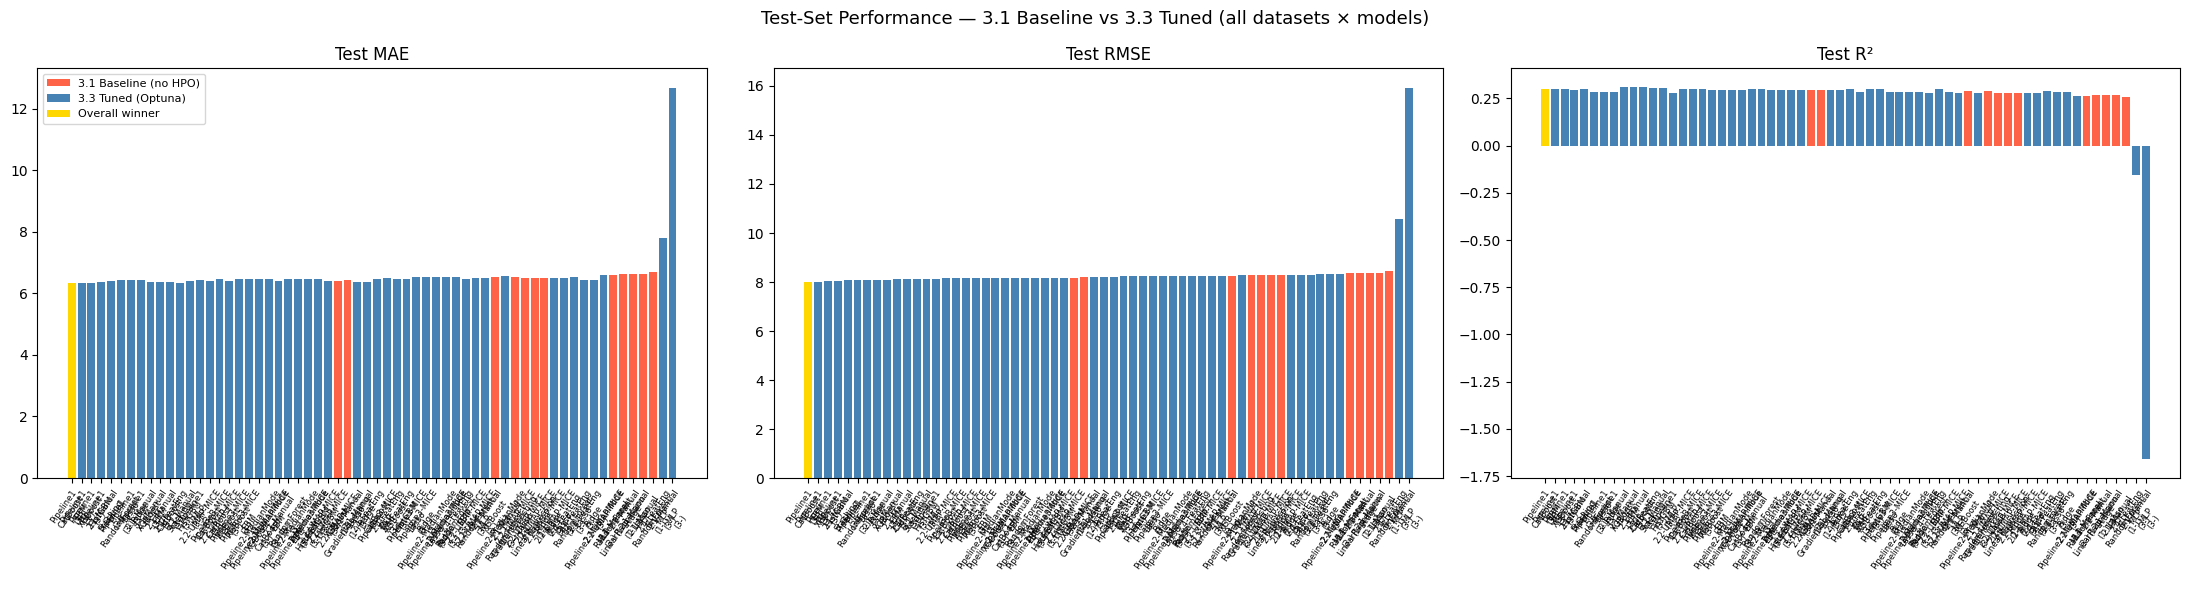

In [ ]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Test-Set Performance — 3.1 Baseline vs 3.3 Tuned (all datasets × models)', fontsize=13)

all_rows = combined_df.to_dicts()
labels   = [f'{r["Dataset"]}\n{r["Model"]}\n({r["Source"][2:4]})' for r in all_rows]
colors   = ['tomato' if r['Source'] == '3.1-Baseline' else 'steelblue' for r in all_rows]
colors[0] = 'gold'   # mark overall winner

for ax, metric in zip(axes, ['Test MAE', 'Test RMSE', 'Test R²']):
    values = [r[metric] for r in all_rows]
    ax.bar(labels, values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=55, labelsize=6)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',    label='3.1 Baseline (no HPO)'),
    Patch(facecolor='steelblue', label='3.3 Tuned (Optuna)'),
    Patch(facecolor='gold',      label='Overall winner'),
]
axes[0].legend(handles=legend_elements, fontsize=8)
plt.tight_layout()
plt.show()

## 8. CV vs Test RMSE Gap — Overfitting Diagnostic

A large positive gap (Test RMSE >> CV RMSE) signals overfitting.  
A negative gap (Test RMSE < CV RMSE) may indicate the test set is slightly easier than training.

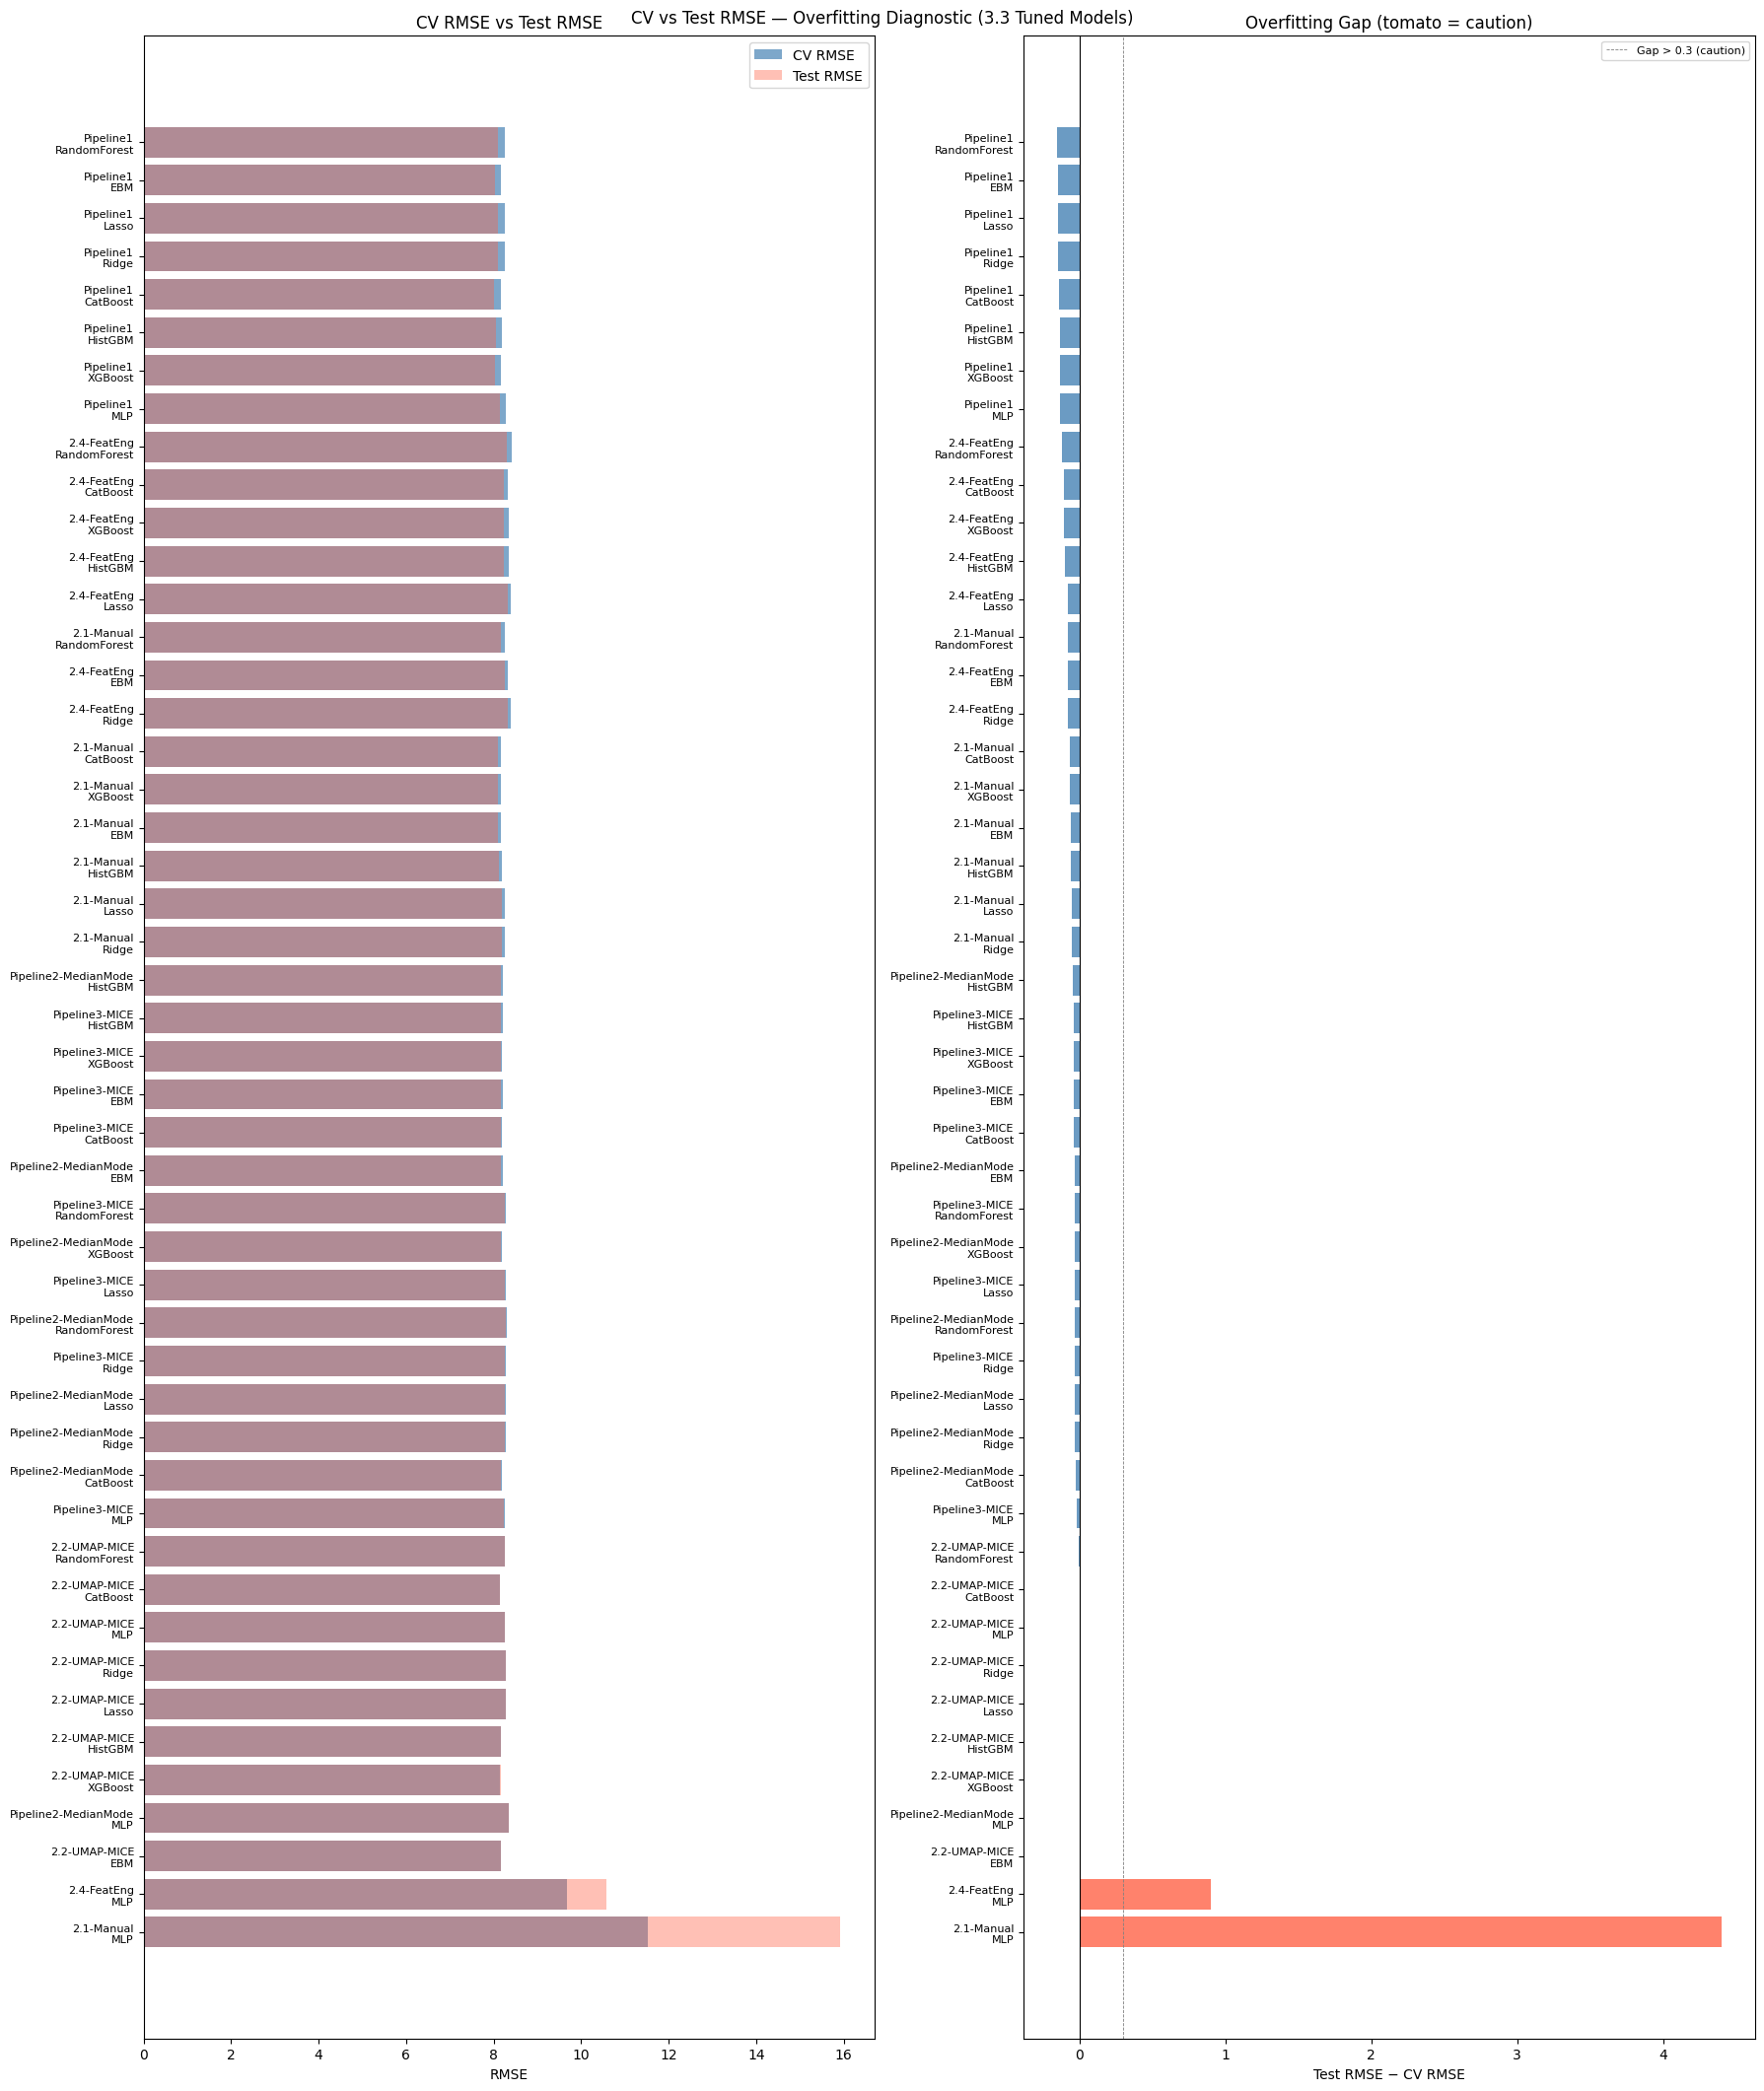


Models with gap > 0.3 (potential overfit):
  2.1-Manual × MLP                               gap=+4.4031
  2.4-FeatEng × MLP                              gap=+0.8998


In [ ]:
import math

gap_rows = []
for ds_label, models_dict in all_results_33.items():
    for mdl_name, res in models_dict.items():
        cv_r   = res['cv_rmse']
        test_r = res['test_rmse']
        if math.isnan(cv_r):
            continue
        gap_rows.append({
            'Label':     f'{ds_label}\n{mdl_name}',
            'CV RMSE':   cv_r,
            'Test RMSE': test_r,
            'Gap':       test_r - cv_r,
        })

gap_df = sorted(gap_rows, key=lambda x: x['Gap'], reverse=True)

labels_g     = [r['Label']    for r in gap_df]
cv_vals      = [r['CV RMSE']  for r in gap_df]
test_vals    = [r['Test RMSE']for r in gap_df]
gaps         = [r['Gap']      for r in gap_df]
gap_colors   = ['tomato' if g > 0.3 else 'steelblue' for g in gaps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, max(5, len(gap_df) * 0.45)))
fig.suptitle('CV vs Test RMSE — Overfitting Diagnostic (3.3 Tuned Models)', fontsize=12)

y_pos = range(len(gap_df))
ax1.barh(y_pos, cv_vals,   alpha=0.7, color='steelblue', label='CV RMSE')
ax1.barh(y_pos, test_vals, alpha=0.4, color='tomato',    label='Test RMSE')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels_g, fontsize=8)
ax1.set_xlabel('RMSE')
ax1.set_title('CV RMSE vs Test RMSE')
ax1.legend()

ax2.barh(y_pos, gaps, color=gap_colors, alpha=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axvline(0.3, color='grey', linewidth=0.6, linestyle='--', label='Gap > 0.3 (caution)')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels_g, fontsize=8)
ax2.set_xlabel('Test RMSE − CV RMSE')
ax2.set_title('Overfitting Gap (tomato = caution)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nModels with gap > 0.3 (potential overfit):')
flagged = [r for r in gap_df if r['Gap'] > 0.3]
if flagged:
    for r in flagged:
        print(f"  {r['Label'].replace(chr(10), ' × '):<45s}  gap={r['Gap']:+.4f}")
else:
    print('  None — all models generalise well.')